# Fraud Detection in Electricity and Gas Consumption Challenge

This notebook covers the different steps involed in the FDEGCC Challenge. 
The data was downloaded form : [zindi.africa](https://zindi.africa/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/data)

- Steps not covered in this notebook:
    - The two main .zip files were downloaded and organized into folders.
    - Please read the file descriptions [here](https://zindi.africa/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/data)

This notebook covers:
- Downloading the data straight from Zindi and onto colab
- Loading the data and carrying out EDA to understand the data and prepare for modelling 
- Preprocessing the data and feature engineering 
- Creating a simple LGBM model and predicting on the test set
- Prepare submission file and save as csv
- Some tips on how to improve model performance and your score

# Workflow Flowchart

+----------------------------------------------------------+
|              1. LOAD DATA                                |
| - Import libraries                                       |
| - Load train/test CSV files                              |
| - Do simple EDA (shape, info, missing,imbalance check)   |
+----------------------------------------------------------+
                    |
                    v
+------------------------------------------+
|      2. PREPROCESS & FEATURE ENGINEERING  |
| - Handle missing values                   |
| - Encode categorical features             |
| - Scale or transform if needed            |
| - Create new useful features              |
+------------------------------------------+
                    |
                    v
+------------------------------------------+
|         3. TRAIN LGBM MODEL               |
| - (Split train/validation data)           |
| - Train LightGBM classifier/regressor     |
| - Predict on test set                     |
+------------------------------------------+
                    |
                    v
+------------------------------------------+
|       4. PREPARE SUBMISSION FILE          |
| - Combine predictions into DataFrame      |
| - Match required submission format        |
| - Save as CSV                             |
+------------------------------------------+
                    |
                    v
+------------------------------------------+
|     5. IMPROVE MODEL PERFORMANCE         |
| - Hyperparameter tuning                  |
| - Better feature engineering             |
| - Cross-validation                       |
| - Try other models / stacking            |
+------------------------------------------+


# 1. Load Data

## Data Organisation
The data used in this project is saved as follows

**data**

   * **a. fraud-detection-tunisian**
        - Fraud_Detection_Starter.ipynb
        - SampleSubmission.csv
        - test.zip
        - train.zip
   * **b. Content**
        - Test Data
           * client_test
           * invoice_test
        - Train Data
           * client_train
           * invoice_train
   * **c. Output**

## Import Libraries and setup global parameters

In [263]:
# Import libs
# os libs
import os
import sys
from pathlib import Path
# DS libs
import numpy as np
import pandas as pd
# DV libs
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ML libs
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import lightgbm as lgb
import joblib   # to save the model

In [172]:
## Output Tables
# Set up print options for cleaner output in the console
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

## Plotting
# --- 1. Style Sheet ---
# 'ggplot', 'fivethirtyeight', 'seaborn-v0_8', 'dark_background' are popular.
plt.style.use('seaborn-v0_8') 
# 

# --- 2. Customizing Global Parameters (Fine-tuning) ---

# Set a new default color cycle (for lines, bars, etc.)
# Using a Colorblind-Friendly Palette (see Palettes section below)
new_color_cycle = ['#004488', '#DDAA33', '#BB5566', '#009988', '#EE7733'] 
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=new_color_cycle)
# Set global font sizes
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 12

# Other common settings
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['grid.alpha'] = 0.5
mpl.rcParams['figure.figsize'] = (10, 6) # Default figure size

# All subsequent calls to plt.plot(), ax.bar(), etc., will use these settings

## Some Colorblind-Friendly Palettes
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']	# Excellent for 7-8 categories. High contrast and accessibility.
ibm_design = ['#648fff', '#ffb000', '#dc267f', '#fe6100', '#785ef0', '#000000']	# Modern, bold, and distinct. Good for up to 6 categories.
tols_muted	= ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933', '#DDCC77', '#CC6677']	# Another strong choice, particularly good when printed in grayscale.
matplotlib_tab10 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']	# Matplotlib's default, generally good, but sometimes lacks high contrast.


## Setup work env and directories

In [173]:
CURRENT_DIR = Path.cwd()

ROOT_DIR = CURRENT_DIR.parents[0]

DATA_DIR = os.path.join(ROOT_DIR, "data/content")
OUTPUT_DIR = os.path.join(ROOT_DIR, "data/output")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

## Load train/test CSV files 

In [174]:
 # add root dir to the path
sys.path.insert(0, str(ROOT_DIR))

client_train = pd.read_csv(f'{TRAIN_DIR}/client_train.csv', low_memory=False)
invoice_train = pd.read_csv(f'{TRAIN_DIR}/invoice_train.csv', low_memory=False)

client_test = pd.read_csv(f'{TEST_DIR}/client_test.csv', low_memory=False)
invoice_test = pd.read_csv(f'{TEST_DIR}/invoice_test.csv', low_memory=False)

sample_submission = pd.read_csv(f'{DATA_DIR}/SampleSubmission.csv', low_memory=False)

## EDA

### 1) Data Inspection

In [175]:
#Check Dimensions:
print(client_train.shape, invoice_train.shape, client_test.shape, invoice_test.shape)

(135493, 6) (4476749, 16) (58069, 5) (1939730, 16)


In [176]:
# Preview Data:
# 1-a Client table
display(client_train.head())

#Get concise information of each column in dataset
client_train.info()

#Get a summary for all numerical columns
client_train.describe(include='all').T

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.00
1,69,train_Client_1,11,107,29/05/2002,0.00
2,62,train_Client_10,11,301,13/03/1986,0.00
3,69,train_Client_100,11,105,11/07/1996,0.00
4,62,train_Client_1000,11,303,14/10/2014,0.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
disrict,135493.00,NaN,NaN,NaN,63.51,3.35,60.00,62.00,62.00,69.00,69.00
client_id,135493,135493,train_Client_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_catg,135493.00,NaN,NaN,NaN,11.51,4.42,11.00,11.00,11.00,11.00,51.00
region,135493.00,NaN,NaN,NaN,206.16,104.21,101.00,103.00,107.00,307.00,399.00
creation_date,135493,8088,20/11/1997,214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,135493.00,NaN,NaN,NaN,0.06,0.23,0.00,0.00,0.00,0.00,1.00


In [177]:
# Count how many fraud targets are there in client table:
# Count how many times each target value appears
target_counts = client_train.target.value_counts()

# Print the counts
print("Count of each target value:")
print(target_counts)

# Calculate percentages
total_samples = len(client_train)
percentages = target_counts / total_samples * 100

# Print percentages
print("\nPercentage of each target value:")
print(percentages)

Count of each target value:
target
0.00    127927
1.00      7566
Name: count, dtype: int64

Percentage of each target value:
target
0.00   94.42
1.00    5.58
Name: count, dtype: float64


In [178]:
# 1-b Invoice table
display(invoice_train.head())

#Get concise information of each column in dataset
invoice_train.info()

#Get a summary for all numerical columns
invoice_train.describe(include='all').T


,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,4476749,135493,train_Client_116878,439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
invoice_date,4476749,8275,2019-03-09,4127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tarif_type,4476749.00,NaN,NaN,NaN,20.13,13.47,8.00,11.00,11.00,40.00,45.00
counter_number,4476749.00,NaN,NaN,NaN,123058699065.18,1657267274261.93,0.00,121108.00,494561.00,1115161.00,27981145458733.00
counter_statue,4476749,12,0,4379008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
consommation_level_4,4476749.00,NaN,NaN,NaN,52.93,875.47,0.00,0.00,0.00,0.00,547946.00
old_index,4476749.00,NaN,NaN,NaN,17767.00,40366.93,0.00,1791.00,7690.00,21660.00,2800280.00
new_index,4476749.00,NaN,NaN,NaN,18349.70,40953.21,0.00,2056.00,8192.00,22343.00,2870972.00
months_number,4476749.00,NaN,NaN,NaN,44.83,3128.34,0.00,4.00,4.00,4.00,636624.00


In [255]:
# ---------------------------------------------------------
# Fix date columns explicitly
# ---------------------------------------------------------
# ------ Train data -------
# 1. client table
client_train["creation_date"] = pd.to_datetime(
    client_train["creation_date"], 
    format="%d/%m/%Y",      # or infer_datetime_format=True
    errors="raise"          # switch to "coerce" if you prefer NaT
)

# 2. invoice table
invoice_train["invoice_date"] = pd.to_datetime(
    invoice_train["invoice_date"], 
    errors="raise"
)

# quick sanity check
print("creation_date dtype:", client_train["creation_date"].dtype)
print("invoice_date dtype :", invoice_train["invoice_date"].dtype)

# ------ Test data -------
# 1. client table
client_test["creation_date"] = pd.to_datetime(
    client_test["creation_date"], 
    format="%d/%m/%Y",      # or infer_datetime_format=True
    errors="raise"          # switch to "coerce" if you prefer NaT
)

# 2. invoice table
invoice_test["invoice_date"] = pd.to_datetime(
    invoice_test["invoice_date"], 
    errors="raise"
)

# quick sanity check
print("creation_date dtype:", client_test["creation_date"].dtype)
print("invoice_date dtype :", invoice_test["invoice_date"].dtype)

creation_date dtype: datetime64[ns]
invoice_date dtype : datetime64[ns]
creation_date dtype: datetime64[ns]
invoice_date dtype : datetime64[ns]


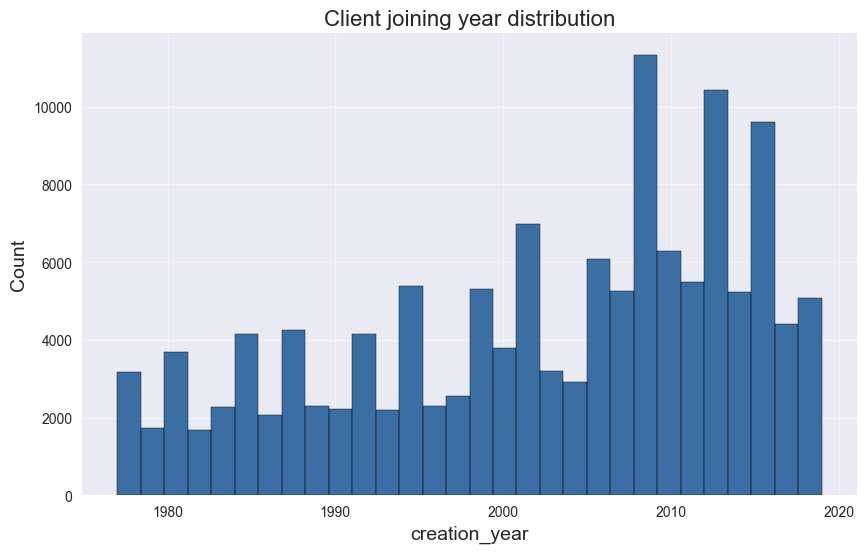

In [180]:
# creation_date distribution (date client joined)
client_train["creation_year"] = client_train["creation_date"].dt.year
sns.histplot(client_train["creation_year"], bins=30, kde=False)
plt.title("Client joining year distribution")
plt.show()

**Variable definitions**

***Invoice data***

- Client_id: Unique id for the client
- Invoice_date: Date of the invoice
- Tarif_type: Type of tax
- Counter_number:
- Counter_statue: takes up to 5 values such as working fine, not working, on hold statue, ect
- Counter_code:
- Reading_remarque: notes that the STEG agent takes during his visit to the client (e.g: If the counter shows something wrong, the agent gives a bad score)
- Counter_coefficient: An additional coefficient to be added when standard consumption is exceeded
- Consommation_level_1: Consumption_level_1
- Consommation_level_2: Consumption_level_2
- Consommation_level_3: Consumption_level_3
- Consommation_level_4: Consumption_level_4
- Old_index: Old index
- New_index: New index
- Months_number: Month number
- Counter_type: Type of counter


**Variable definitions**

***Client:***

- Client_id: Unique id for client
- District: District where the client is
- Client_catg: Category client belongs to
- Region: Area where the client is
- Creation_date: Date client joined
- Target: fraud:1 , not fraud: 0


### 2) Basic Data Quality Checks

In [181]:
# check for missing values
invoice_train.isnull().sum()


client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
                       ..
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
Length: 16, dtype: int64

In [182]:
# check for missing values
client_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
creation_year    0
dtype: int64

In [183]:
# check for missing values
invoice_test.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
                       ..
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
Length: 16, dtype: int64

In [184]:
# check for missing values
client_test.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
dtype: int64

In [185]:
# Check Duplicates:
## (A) Identify duplicate rows

# 1. Check how many duplicates exist
#total_duplicates_invoice_train = invoice_train.duplicated().sum()
#print(f"Total duplicate rows found in invoice_train df: {total_duplicates_invoice_train}")

#total_duplicates_client_train = client_train.duplicated().sum()
#print(f"Total duplicate rows found in client_train df: {total_duplicates_client_train}")

In [186]:
# 2. View the duplicate rows (showing the second and subsequent occurrences)
#duplicate_rows_invoice_train = invoice_train[invoice_train.duplicated(keep='first')]
#print("\nExample of duplicate rows in invoice_train:")
#print(duplicate_rows_invoice_train.head())

In [187]:
## (B) Remove duplicate rows

# Create a new DataFrame without the duplicates
#invoice_train_duplicate_removed = invoice_train.drop_duplicates(keep='first')

# Verify the size reduction
#print(f"\nOriginal shape: {invoice_train.shape}")
#print(f"Cleaned shape: {invoice_train_duplicate_removed.shape}")

In [188]:
# Check Duplicates:
## (A) Identify duplicate rows

# 1. Check how many duplicates exist
#total_duplicates_invoice_test = invoice_test.duplicated().sum()
#print(f"Total duplicate rows found in invoice_test df: {total_duplicates_invoice_test}")

#total_duplicates_client_test = client_test.duplicated().sum()
#print(f"Total duplicate rows found in client_test df: {total_duplicates_client_test}")

In [189]:
## (B) Remove duplicate rows

# Create a new DataFrame without the duplicates
#invoice_test_duplicate_removed = invoice_test.drop_duplicates(keep='first')

# Verify the size reduction
#print(f"\nOriginal shape: {invoice_test.shape}")
#print(f"Cleaned shape: {invoice_test_duplicate_removed.shape}")

In [190]:
# Getting unique values on the invoice train data
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [191]:
# Getting unique values on the client train data
for col in client_train.columns:
    print(f"{col} - {client_train[col].nunique()}")

disrict - 4
client_id - 135493
client_catg - 3
region - 25
creation_date - 8088
target - 2
creation_year - 43


In [192]:
# Univariate Analysis for Numerical Features

## Client Data - None clearly numerical (dates will be transformed later)
## Invoice Data - "consommation_level_1, old_index, new_index, months_number"

## Step (a): Descriptive Statistics

numerical_cols = ['consommation_level_1', 'consommation_level_2', 'old_index', 'new_index', 'months_number', 'counter_coefficient']

print("--- Descriptive Statistics (Invoice Data) ---")
print(invoice_train[numerical_cols].describe().T)

--- Descriptive Statistics (Invoice Data) ---
                          count     mean      std  min     25%     50%      75%        max
consommation_level_1 4476749.00   410.98   757.31 0.00   79.00  274.00   600.00  999910.00
consommation_level_2 4476749.00   109.32  1220.12 0.00    0.00    0.00     0.00  999073.00
old_index            4476749.00 17767.00 40366.93 0.00 1791.00 7690.00 21660.00 2800280.00
new_index            4476749.00 18349.70 40953.21 0.00 2056.00 8192.00 22343.00 2870972.00
months_number        4476749.00    44.83  3128.34 0.00    4.00    4.00     4.00  636624.00
counter_coefficient  4476749.00     1.00     0.31 0.00    1.00    1.00     1.00      50.00


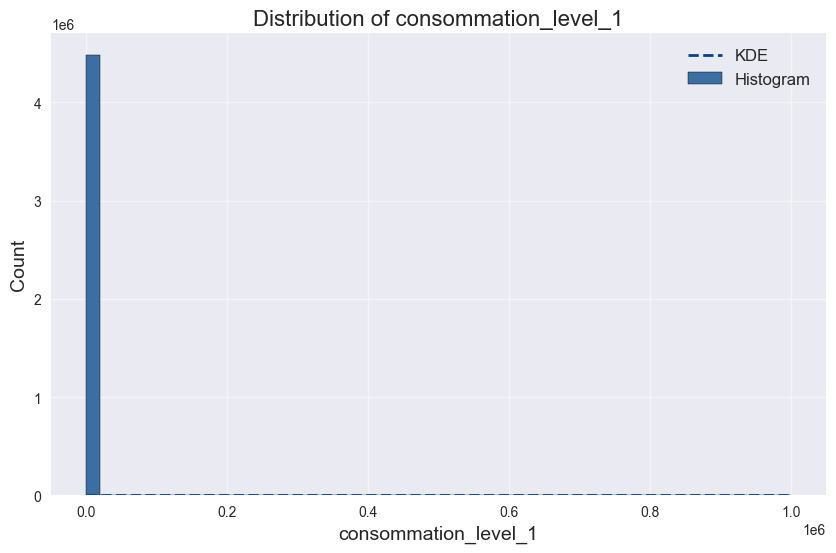

In [193]:
## Step (b): Distribution Visualizations (Histograms & KDE)

feature = 'consommation_level_1'

# 1. plt.figure() is now optional for figure size, 
#    as it's set globally by mpl.rcParams['figure.figsize'] = (10, 6)
plt.figure() 

# Histogram
sns.histplot(
    invoice_train[feature], 
    bins=50, 
    kde=False, 
    label='Histogram'
)

# KDE
sns.kdeplot(
    invoice_train[feature], 
    linestyle='--', 
    label='KDE'
)

# plt.title(), plt.xlabel(), and plt.legend() automatically use the 
# global font sizes set in mpl.rcParams.
plt.title(f'Distribution of {feature}')
plt.xlabel(feature)
plt.legend()
plt.show()

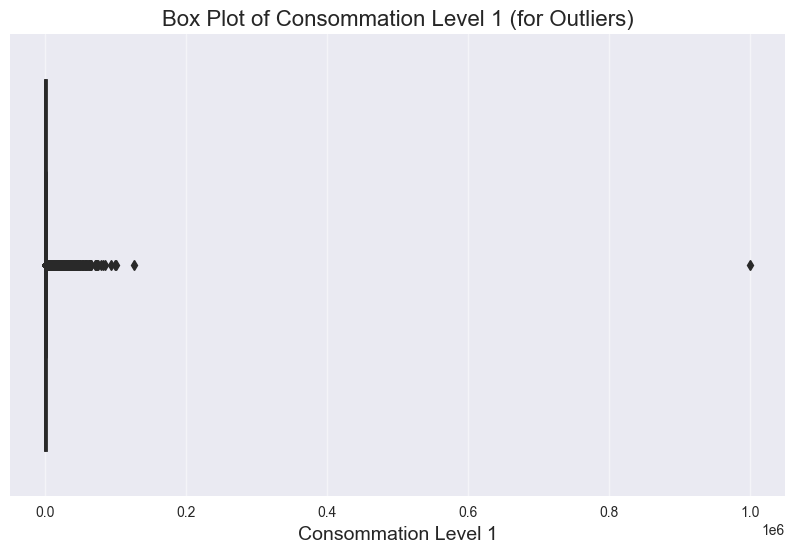

In [194]:
## Step (c): Outlier Detection (Box Plots)

plt.figure()
sns.boxplot(x=invoice_train['consommation_level_1'])
plt.title('Box Plot of Consommation Level 1 (for Outliers)')
plt.xlabel('Consommation Level 1')
plt.show()

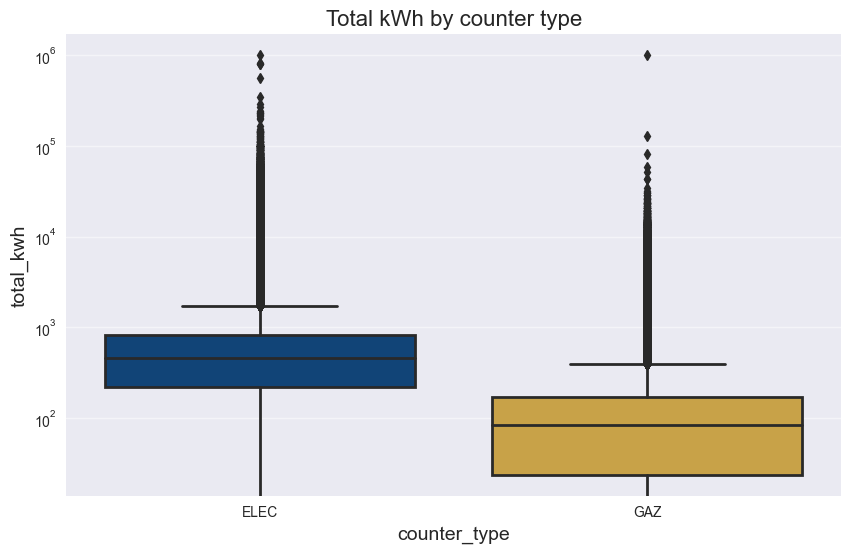

In [195]:
# Consumption distribution (total kWh)
invoice_train["total_kwh"] = (invoice_train[["consommation_level_1","consommation_level_2",
                                 "consommation_level_3","consommation_level_4"]]
                        .sum(axis=1))
sns.boxplot(x="counter_type", y="total_kwh", data=invoice_train)
plt.yscale("log") 
plt.title("Total kWh by counter type")
plt.show()


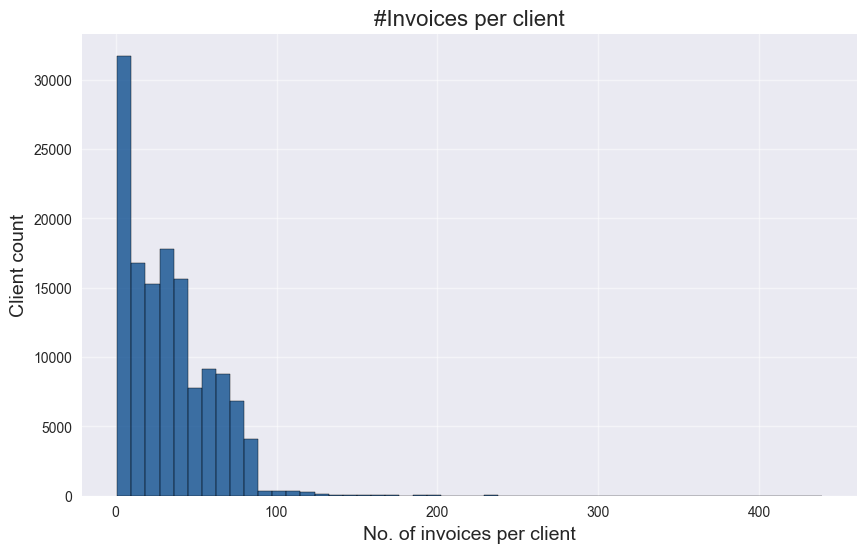

In [196]:
# Invoice frequency per client
inv_per_client = invoice_train.groupby("client_id").size()
sns.histplot(inv_per_client, bins=50, kde=False)
plt.title("#Invoices per client")
plt.xlabel('No. of invoices per client')
plt.ylabel('Client count')
plt.show()

Interpretation:
The distribution is heavily right-skewed:
- Most clients (the tall bar on the left) have very few invoices – apparently 0–20.
- A long tail stretches to 400 invoices, but those clients are rare.
Business meaning:
- The majority of customers are low-activity (possibly residential or small business).
- The right tail represents high-activity customers (large sites, factories, metering errors, or aggregated accounts).
- Any future model should account for this skew (e.g., log-transform “number_of_invoices” or treat it as a frequency feature).

Modelling consequence:
- If you aggregate invoice-level data to one row per client, the frequency features will have extremely different scales.
- Consider outlier clipping, log-transform, or bucketising ("1-5", "6-20", ">20" invoices) to stabilise variance.

**Few invoices dominate the client base, while a tiny fraction generates hundreds.**


          TARGET IMBALANCE CHECK           
target
0.00   94.42
1.00    5.58
Name: proportion, dtype: float64


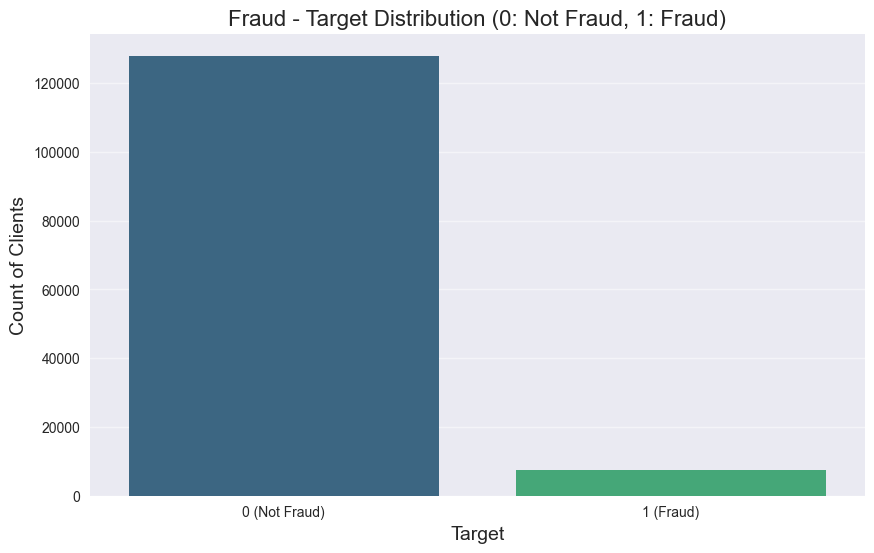

In [197]:
#Visualize fraudulent activities
# Calculate the counts and proportions
target_counts = client_train['target'].value_counts()
target_proportions = client_train['target'].value_counts(normalize=True) * 100

print("\n=========================================")
print("          TARGET IMBALANCE CHECK           ")
print("===========================================")
print(target_proportions)

# Plotting the distribution
plt.figure()
sns.countplot(x='target', data=client_train, palette= 'viridis')
plt.title('Fraud - Target Distribution (0: Not Fraud, 1: Fraud)')
plt.xlabel('Target')
plt.ylabel('Count of Clients')
plt.xticks([0, 1], ['0 (Not Fraud)', '1 (Fraud)'])
plt.show()

In [198]:
# Univariate Analysis for Categorical Features

## Client Data	- district, client_catg, region
## Invoice Data	- tarif_type, counter_statue, counter_type


What to Look For:

- Dominant Categories: Do one or two categories make up most of the data? If so, rare categories might need to be grouped together.
- Low Cardinality: Are there too many categories (high cardinality)? If a category only appears once or twice, it might be noise.

In [199]:
# ---  Defining the Categorical Columns to Analyze ---

client_categorical_cols = ['disrict', 'client_catg', 'region']
invoice_categorical_cols = [
    'tarif_type', 
    'counter_statue', 
    'counter_code', 
    'reading_remarque', 
    'counter_type'
]

In [200]:
# ================================================
# UNIVARIATE ANALYSIS - CLIENT CATEGORICAL FEATURES
# ================================================

# --- 1. PRINT STATISTICS FOR EACH CATEGORICAL COLUMN ---

# Add a clear header
print("\n" + "=" * 50)
print("CATEGORICAL FEATURES - FREQUENCY TABLES")
print("=" * 50)

# Loop through each categorical column
for column_name in client_categorical_cols:
    
    # Create a separator for readability
    print(f"\n{'='*40}")
    print(f"FEATURE: {column_name}")
    print(f"{'='*40}")
    
    # Count how many times each unique value appears
    # Example: If column has values ['A', 'B', 'A', 'C'], 
    # value_counts() returns: A=2, B=1, C=1
    frequency_counts = client_train[column_name].value_counts()
    
    # Calculate percentages for each unique value
    # normalize=True gives proportions (like 0.25, 0.50)
    # mul(100) converts to percentages (25%, 50%)
    # round(2) rounds to 2 decimal places
    percentages = client_train[column_name].value_counts(normalize=True).mul(100).round(2)
    
    # Print the table header
    print(f"{'Category':<20} {'Count':<10} {'Percentage':<10}")
    print("-" * 40)
    
    # Print each row of the table
    for category, count in frequency_counts.items():
        # Get the percentage for this specific category
        percentage_value = percentages.loc[category]
        
        # Print formatted row
        print(f"{str(category):<20} {count:<10} {percentage_value:<10}%")
    
    # Add spacing before next feature
    print()


# --- 2. CREATE PLOTS FOR EACH CATEGORICAL COLUMN ---
# (This section creates and saves plots separately)

print("\n" + "=" * 50)
print("CATEGORICAL FEATURES - CREATING PLOTS")
print("=" * 50)

# Loop through each categorical column again, this time for plotting
for column_name in client_categorical_cols:
    
    print(f"\nCreating plot for: {column_name}")
    
    # STEP 1: Count frequencies for this column
    # We need this to order bars from most frequent to least frequent
    frequency_counts = client_train[column_name].value_counts()
    
    # STEP 2: Create a new figure for the plot
    plt.figure(figsize=(10, 6))  # Width=10 inches, Height=6 inches
    
    # STEP 3: Create the bar plot using seaborn
    # order=counts.index sorts bars by frequency (highest first)
    # palette='viridis' gives a nice color scheme
    bar_plot = sns.countplot(
        data=client_train,           # Use our client data
        x=column_name,              # Plot this column on x-axis
        order=frequency_counts.index, # Order bars by frequency
        palette='viridis'           # Color scheme
    )
    
    # STEP 4: Customize the plot appearance
    plt.title(f'Distribution of {column_name}', fontsize=16, fontweight='bold')
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel('Number of Clients', fontsize=12)
    
    # Rotate x-axis labels if they're long (45 degrees)
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on top of each bar
    for container in bar_plot.containers:
        bar_plot.bar_label(container, fmt='%.0f', padding=3)
    
    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()
    
    # STEP 5: Save the plot as an image file
    # Create a filename for this specific column
    plot_filename = f'client_distribution_{column_name}.png'
    
    # Create the full path by joining directory and filename
    full_path = os.path.join(OUTPUT_DIR, plot_filename)
    
    # Save the figure to the specified path
    plt.savefig(full_path, dpi=300)  # dpi=300 gives high resolution
    
    # STEP 6: Close the plot to free up memory
    plt.close()
    
    # Confirm the plot was saved
    print(f" Saved: {plot_filename}")

# Final message
print("\n" + "=" * 50)
print("ANALYSIS COMPLETE!")
print(f"• Printed frequency tables for {len(client_categorical_cols)} features")
print(f"• Saved {len(client_categorical_cols)} plots to: {OUTPUT_DIR}")
print("=" * 50)


CATEGORICAL FEATURES - FREQUENCY TABLES

FEATURE: disrict
Category             Count      Percentage
----------------------------------------
62                   40353      29.78     %
69                   34231      25.26     %
60                   31922      23.56     %
63                   28987      21.39     %


FEATURE: client_catg
Category             Count      Percentage
----------------------------------------
11                   131494     97.05     %
12                   2321       1.71      %
51                   1678       1.24      %


FEATURE: region
Category             Count      Percentage
----------------------------------------
101                  33770      24.92     %
104                  12865      9.49      %
311                  12406      9.16      %
107                  9998       7.38      %
301                  9544       7.04      %
103                  8964       6.62      %
306                  6044       4.46      %
303                  5982       

In [201]:
# =================================================
# UNIVARIATE ANALYSIS - INVOICE CATEGORICAL FEATURES
# =================================================

# --- 1. PRINT STATISTICS FOR EACH CATEGORICAL COLUMN ---
# (This section prints frequency tables without creating plots)

# Add a clear header
print("\n" + "=" * 50)
print("INVOICE DATA - CATEGORICAL FEATURES FREQUENCY TABLES")
print("=" * 50)

# Define how many top categories to show (prevents long outputs)
TOP_CATEGORIES_TO_SHOW = 10

# Loop through each categorical column in the invoice data
for column_name in invoice_categorical_cols:
    
    # Create a clear separator for each feature
    print(f"\n{'='*50}")
    print(f"INVOICE FEATURE: {column_name}")
    print(f"{'='*50}")
    
    # STEP 1: Count how many times each unique value appears
    # Example: Count how many invoices have each payment method
    frequency_counts = invoice_train[column_name].value_counts()
    
    # STEP 2: Calculate percentages for each category
    # normalize=True gives decimal proportions (0.25 = 25%)
    # mul(100) converts to percentages (25%)
    # round(2) rounds to 2 decimal places
    percentages = invoice_train[column_name].value_counts(normalize=True).mul(100).round(2)
    
    # STEP 3: Print summary information
    total_categories = len(frequency_counts)
    print(f"Total unique values: {total_categories}")
    
    # Check if we have many categories - if so, we'll only show top ones
    if total_categories > TOP_CATEGORIES_TO_SHOW:
        print(f"Note: Showing top {TOP_CATEGORIES_TO_SHOW} categories only (out of {total_categories})")
    
    # STEP 4: Print the table header
    print(f"\n{'Category':<20} {'Count':<12} {'Percentage':<10}")
    print("-" * 42)
    
    # STEP 5: Print each row of the table
    # We use .head(TOP_CATEGORIES_TO_SHOW) to limit output
    for category, count in frequency_counts.head(TOP_CATEGORIES_TO_SHOW).items():
        # Get the percentage for this specific category
        percentage_value = percentages.loc[category]
        
        # Print formatted row with aligned columns
        print(f"{str(category):<20} {count:<12} {percentage_value:<10.2f}%")
    
    # If we have more categories than we're showing, add a note
    if total_categories > TOP_CATEGORIES_TO_SHOW:
        print(f"... and {total_categories - TOP_CATEGORIES_TO_SHOW} more categories")
    
    # Add spacing before the next feature
    print()


# --- 2. CREATE PLOTS FOR EACH CATEGORICAL COLUMN ---
# (This section creates and saves plots separately from statistics)

print("\n" + "=" * 50)
print("INVOICE DATA - CREATING DISTRIBUTION PLOTS")
print("=" * 50)

# Loop through each categorical column to create plots
for column_name in invoice_categorical_cols:
    
    print(f"\nCreating distribution plot for: {column_name}")
    
    # STEP 1: Count frequencies for this column
    # We need this for ordering bars in the plot
    frequency_counts = invoice_train[column_name].value_counts()
    
    # STEP 2: Create a new figure for the plot
    # Adjust size based on number of categories
    num_categories = len(frequency_counts)
    
    # Make plot wider if there are many categories
    if num_categories > 10:
        plot_width = max(12, num_categories * 0.5)  # Dynamic width
        plt.figure(figsize=(plot_width, 6))
    else:
        plt.figure(figsize=(10, 6))  # Standard size for few categories
    
    # STEP 3: Create the bar plot
    # Using seaborn's countplot for categorical data
    bar_plot = sns.countplot(
        data=invoice_train,          # Use our invoice data
        x=column_name,              # Plot this column on x-axis
        order=frequency_counts.index, # Order bars by frequency (highest first)
        palette='viridis'           # Color scheme
    )
    
    # STEP 4: Customize the plot appearance
    plt.title(f'Invoice Distribution: {column_name}', fontsize=16, fontweight='bold')
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel('Number of Invoices', fontsize=12)
    
    # Rotate x-axis labels for readability (especially for long category names)
    if num_categories > 5:  # Only rotate if we have several categories
        plt.xticks(rotation=45, ha='right')
    
    # STEP 5: Add value labels on top of each bar
    # This shows the exact count for each category
    for container in bar_plot.containers:
        bar_plot.bar_label(container, fmt='%.0f', padding=3, fontsize=9)
    
    # STEP 6: Adjust layout to prevent labels from being cut off
    plt.tight_layout()
    
    # STEP 7: Save the plot as an image file
    # Create a descriptive filename
    plot_filename = f'invoice_distribution_{column_name}.png'
    
    # Create the full path by joining directory and filename
    full_path = os.path.join(OUTPUT_DIR, plot_filename)
    
    # Save the figure with high resolution
    plt.savefig(full_path, dpi=300, bbox_inches='tight')  # bbox_inches ensures nothing is cut off
    
    # STEP 8: Close the plot to free up memory
    plt.close()
    
    # Confirm the plot was saved
    print(f"✓ Saved: {plot_filename}")

# Final summary message
print("\n" + "=" * 50)
print("INVOICE ANALYSIS COMPLETE!")
print("=" * 50)
print(f"• Analyzed {len(invoice_categorical_cols)} categorical features")
print(f"• Printed frequency tables with top {TOP_CATEGORIES_TO_SHOW} categories")
print(f"• Created and saved {len(invoice_categorical_cols)} distribution plots")
print(f"• All plots saved to: {OUTPUT_DIR}")
print("=" * 50)


INVOICE DATA - CATEGORICAL FEATURES FREQUENCY TABLES

INVOICE FEATURE: tarif_type
Total unique values: 17
Note: Showing top 10 categories only (out of 17)

Category             Count        Percentage
------------------------------------------
11                   2679872      59.86     %
40                   1379755      30.82     %
10                   276210       6.17      %
15                   72422        1.62      %
45                   17552        0.39      %
13                   11656        0.26      %
14                   11611        0.26      %
12                   11345        0.25      %
29                   10090        0.23      %
9                    6039         0.13      %
... and 7 more categories


INVOICE FEATURE: counter_statue
Total unique values: 12
Note: Showing top 10 categories only (out of 12)

Category             Count        Percentage
------------------------------------------
0                    4379008      97.82     %
1                    74036 

# 2) Preprocess data and Feature Engineering

## 2a. Build a single, clean, merged table

In [148]:

# ----  Merge invoice and client tables ----
# We use INNER JOIN so we keep ONLY clients that have ≥ 1 invoice.
#   - Guarantees every row in the resulting table has consumption data
#   - Drops clients who never received an invoice (they are useless for fraud detection)
train = invoice_train.merge(client_train, on='client_id', how='inner')
test  = invoice_test.merge(client_test,  on='client_id', how='inner')

train.head(5)
test.head(5)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date
0,test_Client_0,2018-03-16,11,651208,0,203,8,1,755,0,0,0,19145,19900,8,ELEC,62,11,307,28/05/2002
1,test_Client_0,2014-03-21,11,651208,0,203,8,1,1067,0,0,0,13725,14792,8,ELEC,62,11,307,28/05/2002
2,test_Client_0,2014-07-17,11,651208,0,203,8,1,0,0,0,0,14792,14792,4,ELEC,62,11,307,28/05/2002
3,test_Client_0,2015-07-13,11,651208,0,203,9,1,410,0,0,0,16122,16532,4,ELEC,62,11,307,28/05/2002
4,test_Client_0,2016-07-19,11,651208,0,203,9,1,412,0,0,0,17471,17883,4,ELEC,62,11,307,28/05/2002


In [ ]:
# encode labels in categorical column
# Convert categorical counter types into numerical values for model compatibility.
# 'ELEC' (electricity) is encoded as 0 and 'GAZ' (gas) is encoded as 1.
# This mapping ensures consistent numeric representation required for analysis
# and machine learning algorithms.

#.map(d) applies the dictionary d element-wise to the pandas Series.
#Each categorical value is looked up in the dictionary.
#The returned value replaces the original category.
#Unmapped or missing categories become NaN.

d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

## 2b. Create behavioural features (invoice level)

In [152]:
## 02) Create behavioural features (invoice level)
#For every individual invoice row, calculate quantities that describe how this 
# client normally behaves across all their invoices.
#These new columns later become the raw material we aggregate to the client level for fraud detection.


# ensure rows are in chronological order per client (needed for diff/pct_change)
train = train.sort_values(['client_id', 'invoice_date'])

# ---------------------------------------------------------
# 2.1  Consumption behaviour per client
# ---------------------------------------------------------
# compute client-level stats and broadcast them back to each invoice row
g = train.groupby('client_id')
train['client_tot_kwh'] = g['total_kwh'].transform('sum')   # total energy ever used
train['client_avg_kwh'] = g['total_kwh'].transform('mean')  # average invoice
train['client_std_kwh'] = g['total_kwh'].transform('std')   # volatility of usage


train.head(5)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,total_kwh,disrict,client_catg,region,creation_date,target,creation_year,client_tot_kwh,client_avg_kwh,client_std_kwh
22,train_Client_0,2005-10-17,11,1335667,0,203,6,1,124,0,0,0,3685,3809,4,ELEC,124,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55
23,train_Client_0,2006-02-24,11,1335667,0,203,6,1,141,0,0,0,3809,3950,4,ELEC,141,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55
24,train_Client_0,2006-06-23,11,1335667,0,203,6,1,162,0,0,0,3950,4112,4,ELEC,162,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55
25,train_Client_0,2006-10-18,11,1335667,0,203,6,1,159,0,0,0,4112,4271,4,ELEC,159,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55
28,train_Client_0,2007-02-26,11,1335667,0,203,6,1,182,0,0,0,4271,4453,4,ELEC,182,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55


In [160]:
# =============================================================================
#  CALCULATE INVOICE FREQUENCY FOR EACH CLIENT
# =============================================================================
# analyzes how often each client gets invoices
# look at the actual gaps between their invoices

# -----------------------------------------------------------------------------
# STEP 1: SORT THE DATA
# -----------------------------------------------------------------------------
# Why sort? Because we need invoices in chronological order to calculate gaps
# We sort by client first, then by date for each client
# -----------------------------------------------------------------------------

# Make a copy of our data to work with (good practice)
invoice_analysis = train.copy()

# Sort the data: first by client_id, then by invoice_date within each client
invoice_analysis = invoice_analysis.sort_values(['client_id', 'invoice_date'])

print(f" Data sorted successfully")
print(f"  - First sorted by: client_id (to group each client's invoices together)")
print(f"  - Then sorted by: invoice_date (to put each client's invoices in order)")
print(f"  - Total rows sorted: {len(invoice_analysis):,}")
print()


 Data sorted successfully
  - First sorted by: client_id (to group each client's invoices together)
  - Then sorted by: invoice_date (to put each client's invoices in order)
  - Total rows sorted: 4,476,749



In [162]:
# -----------------------------------------------------------------------------
# STEP 2: CALCULATE DAYS BETWEEN CONSECUTIVE INVOICES
# -----------------------------------------------------------------------------
# For each client - calculate how many days passed since their last invoice
# -----------------------------------------------------------------------------

# Create a new column to store days since last invoice
# We'll start with NaN (Not a Number) which means "no value yet"
invoice_analysis['days_since_last_invoice'] = None

# Group the data by client_id so we can analyze each client separately
grouped_by_client = invoice_analysis.groupby('client_id')

print("Analyzing each client's invoice pattern...")
print(f"Total unique clients to analyze: {len(grouped_by_client.groups):,}")

# Process each client group
for client_id, client_data in grouped_by_client:
    # client_id: The unique ID for this client (e.g., 'train_Client_0')
    # client_data: All rows belonging to this client
    
    # Sort this client's invoices by date (just to be sure)
    client_data = client_data.sort_values('invoice_date')
    
    # Get the invoice dates for this client
    invoice_dates = client_data['invoice_date']
    
    # Calculate the difference between each date and the previous date
    # .diff() calculates: current_date - previous_date
    # .dt.days converts the difference to number of days (instead of "5 days" format)
    days_diff = invoice_dates.diff().dt.days
    
    # Store the result back in our dataframe
    # We use .loc to update only the rows for this specific client
    invoice_analysis.loc[client_data.index, 'days_since_last_invoice'] = days_diff

print(" Calculated days between invoices for all clients")
print()

# Let's see what we calculated for our sample client
sample_client = 'train_Client_0'
client_sample = invoice_analysis[invoice_analysis['client_id'] == sample_client].sort_values('invoice_date')

print(f"Sample analysis for {sample_client}:")
print("-" * 40)
print(f"{'Invoice Date':<15} {'Days Since Previous':<20}")
print("-" * 40)

for idx, row in client_sample.iterrows():
    date_str = row['invoice_date'].strftime('%Y-%m-%d')
    days_gap = row['days_since_last_invoice']
    
    if pd.isna(days_gap):
        gap_str = "First invoice (no previous)"
    else:
        gap_str = f"{int(days_gap)} days"
    
    print(f"{date_str:<15} {gap_str:<20}")

print()

Analyzing each client's invoice pattern...
Total unique clients to analyze: 135,493
✓ Calculated days between invoices for all clients

Sample analysis for train_Client_0:
----------------------------------------
Invoice Date    Days Since Previous 
----------------------------------------
2005-10-17      First invoice (no previous)
2006-02-24      130 days            
2006-06-23      119 days            
2006-10-18      117 days            
2007-02-26      131 days            
2007-06-27      121 days            
2007-10-25      120 days            
2008-01-04      71 days             
2008-07-28      206 days            
2008-11-25      120 days            
2009-01-04      40 days             
2009-07-27      204 days            
2009-11-24      120 days            
2010-03-29      125 days            
2010-07-22      115 days            
2010-11-24      125 days            
2011-03-30      126 days            
2011-07-22      114 days            
2011-11-22      123 days            

In [163]:
# -----------------------------------------------------------------------------
# STEP 3: CALCULATE AVERAGE GAP FOR EACH CLIENT
# -----------------------------------------------------------------------------
# Now calculate the average time between invoices for each client
# This shows their "typical" billing frequency
# -----------------------------------------------------------------------------

# Create a new column for average gap
invoice_analysis['avg_invoice_gap_days'] = None

# Group by client again to calculate averages
for client_id, client_data in grouped_by_client:
    # Get the days_since_last_invoice for this client
    # Skip the first invoice (it has NaN because there's no previous invoice)
    gaps = client_data['days_since_last_invoice'].dropna()
    
    if len(gaps) > 0:
        # Calculate the mean (average) of the gaps
        avg_gap = gaps.mean()
    else:
        # If only one invoice, we can't calculate an average gap
        avg_gap = None
    
    # Store this average for all rows of this client
    invoice_analysis.loc[client_data.index, 'avg_invoice_gap_days'] = avg_gap

print(" Calculated average invoice gap for all clients")
print()

# Show the average for our sample client
avg_gap_sample = invoice_analysis.loc[
    invoice_analysis['client_id'] == sample_client, 
    'avg_invoice_gap_days'
].iloc[0]

print(f"Average invoice gap for {sample_client}: {avg_gap_sample:.1f} days")
print(f"That's approximately every {avg_gap_sample/30.4:.1f} months")
print()


 Calculated average invoice gap for all clients

Average invoice gap for train_Client_0: 144.1 days
That's approximately every 4.7 months



In [166]:
# -----------------------------------------------------------------------------
# STEP 4: CATEGORIZE BILLING FREQUENCY
# -----------------------------------------------------------------------------
# Convert the average gap into a human-readable category
# Example: 30 days → "Monthly", 90 days → "Quarterly"
# -----------------------------------------------------------------------------

# Define our categories
def categorize_billing_frequency(days):
    """
    Convert number of days into a billing frequency category
    """
    if pd.isna(days):
        return "Unknown (only 1 invoice)"
    elif days <= 7:
        return "Weekly"
    elif days <= 15:
        return "Bi-weekly"
    elif days <= 35:
        return "Monthly"
    elif days <= 65:
        return "Bi-monthly"
    elif days <= 95:
        return "Quarterly"
    elif days <= 185:
        return "Semi-annual"
    elif days <= 370:
        return "Annual"
    else:
        return "Irregular (over 1 year)"

# Apply the categorization to each client
invoice_analysis['billing_frequency_category'] = invoice_analysis['avg_invoice_gap_days'].apply(
    categorize_billing_frequency
)

print(" Categorized billing frequency for all clients")
print()


 Categorized billing frequency for all clients



In [167]:
# -----------------------------------------------------------------------------
# STEP 5: CREATE SUMMARY STATISTICS
# -----------------------------------------------------------------------------
# Let's see what billing patterns are most common in our data
# -----------------------------------------------------------------------------

# Get unique clients and their categories
client_summary = invoice_analysis[['client_id', 'avg_invoice_gap_days', 'billing_frequency_category']].drop_duplicates()

# Count how many clients fall into each category
category_counts = client_summary['billing_frequency_category'].value_counts()

print("Number of clients by billing frequency:")
print("-" * 40)
print(f"{'Frequency':<20} {'Clients':<10} {'Percentage':<10}")
print("-" * 40)

for category, count in category_counts.items():
    percentage = (count / len(client_summary)) * 100
    print(f"{category:<20} {count:<10} {percentage:.1f}%")

print()

Number of clients by billing frequency:
----------------------------------------
Frequency            Clients    Percentage
----------------------------------------
Semi-annual          61466      45.4%
Quarterly            34317      25.3%
Bi-monthly           19409      14.3%
Annual               11392      8.4%
Unknown (only 1 invoice) 4212       3.1%
Irregular (over 1 year) 1899       1.4%
Monthly              1470       1.1%
Weekly               1163       0.9%
Bi-weekly            165        0.1%



In [169]:
# -----------------------------------------------------------------------------
# STEP 6: ADD THE RESULTS BACK TO ORIGINAL DATA
# -----------------------------------------------------------------------------
# Update the original 'train' dataframe with our calculated columns
# -----------------------------------------------------------------------------

# Update the original dataframe
train['days_since_last_invoice'] = invoice_analysis['days_since_last_invoice']
train['avg_invoice_gap_days'] = invoice_analysis['avg_invoice_gap_days']
train['billing_frequency_category'] = invoice_analysis['billing_frequency_category']

print(" Added new columns to original dataframe:")
print(f"  1. days_since_last_invoice - Gap from previous invoice (in days)")
print(f"  2. avg_invoice_gap_days - Average time between invoices")
print(f"  3. billing_frequency_category - Human-readable category")
print()

 Added new columns to original dataframe:
  1. days_since_last_invoice - Gap from previous invoice (in days)
  2. avg_invoice_gap_days - Average time between invoices
  3. billing_frequency_category - Human-readable category



Step 7: Visualize billing frequency distribution
Preparing data for visualization...
 Prepared data: 4,472,537 clients with valid invoice gaps
 Found 9 different billing frequency categories

Creating histogram of average invoice gaps...
 Histogram created
Creating bar chart of billing categories...
 Bar chart created

Visualization saved as: /Users/subhadrachakrabarty/Desktop/data_science/neuefrische/ds_ai_bootcamp/project_neuefrische/week_07_ml_project/ds-ml-project/data/output/billing_frequency_analysis_improved.png


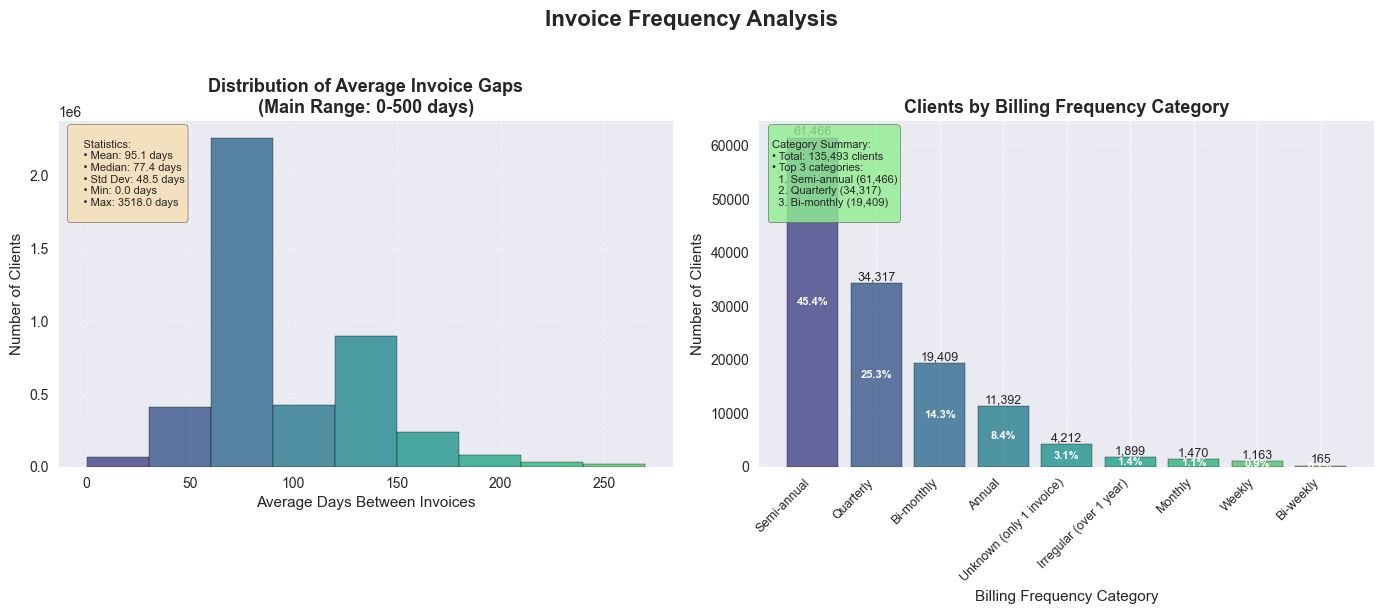

In [212]:
# -----------------------------------------------------------------------------
# STEP 7: VISUALIZE THE RESULTS
# -----------------------------------------------------------------------------
# Create a simple visualization to understand the distribution
# -----------------------------------------------------------------------------

print("="*60)
print("Step 7: Visualize billing frequency distribution")
print("="*60)

print("Preparing data for visualization...")

# Get unique clients and their billing categories
client_summary = train[['client_id', 'avg_invoice_gap_days', 'billing_frequency_category']].drop_duplicates()

# Count clients in each category using value_counts()
category_counts = client_summary['billing_frequency_category'].value_counts()

# Get valid average gaps (remove NaN values)
valid_gaps = train['avg_invoice_gap_days'].dropna()

print(f" Prepared data: {len(valid_gaps):,} clients with valid invoice gaps")
print(f" Found {len(category_counts)} different billing frequency categories")
print()

# -------------------------------------------------------------------------
# CREATE THE VISUALIZATION
# -------------------------------------------------------------------------

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------------------------------------------------
# PLOT 1: HISTOGRAM OF AVERAGE INVOICE GAPS
# -------------------------------------------------------------------------

print("Creating histogram of average invoice gaps...")

# Calculate percentiles to understand the distribution
p95 = valid_gaps.quantile(0.95)  # 95th percentile
p99 = valid_gaps.quantile(0.99)  # 99th percentile

# Use reasonable bins based on the data distribution
bins = np.arange(0, min(p99 * 1.1, 500), 30)  # 30-day increments up to 500 days or p99

# Create the histogram
n, bins, patches = ax1.hist(
    valid_gaps, 
    bins=bins,
    edgecolor='black', 
    alpha=0.8,
    range=(0, min(p99 * 1.1, 500))
)

# Apply viridis gradient across bars (lighter to darker)
viridis_cmap = plt.cm.viridis
for i, patch in enumerate(patches):
    # Gradient from light viridis (0.2) to dark viridis (0.8)
    color_value = 0.2 + (0.6 * i / len(patches))
    patch.set_facecolor(viridis_cmap(color_value))

# Customize the histogram
ax1.set_xlabel('Average Days Between Invoices', fontsize=11)
ax1.set_ylabel('Number of Clients', fontsize=11)
ax1.set_title('Distribution of Average Invoice Gaps\n(Main Range: 0-500 days)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')


ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
         fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

print(" Histogram created")

# -------------------------------------------------------------------------
# PLOT 2: BAR CHART OF BILLING FREQUENCY CATEGORIES
# -------------------------------------------------------------------------

print("Creating bar chart of billing categories...")

# Sort categories by count (descending)
sorted_categories = category_counts.sort_values(ascending=False)

# Create color gradient based on count
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_categories)))

# Create bar chart
bars = ax2.bar(
    range(len(sorted_categories)),
    sorted_categories.values,
    color=colors,
    edgecolor='black',
    alpha=0.8
)

# Customize the bar chart
ax2.set_xlabel('Billing Frequency Category', fontsize=11)
ax2.set_ylabel('Number of Clients', fontsize=11)
ax2.set_title('Clients by Billing Frequency Category', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(sorted_categories)))
ax2.set_xticklabels(sorted_categories.index, rotation=45, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add value labels on bars
for bar, value in zip(bars, sorted_categories.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 5,
            f'{value:,}', ha='center', va='bottom', fontsize=9)

# Add percentage labels
total_clients = sorted_categories.sum()
for i, (bar, value) in enumerate(zip(bars, sorted_categories.values)):
    percentage = (value / total_clients) * 100
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height/2,
            f'{percentage:.1f}%', ha='center', va='center', 
            fontsize=8, fontweight='bold', color='white')

# Add summary text box
category_text = f"""
Category Summary:
• Total: {total_clients:,} clients
• Top 3 categories:
  1. {sorted_categories.index[0]} ({sorted_categories.values[0]:,})
  2. {sorted_categories.index[1]} ({sorted_categories.values[1]:,})
  3. {sorted_categories.index[2]} ({sorted_categories.values[2]:,})
"""

ax2.text(0.02, 0.98, category_text, transform=ax2.transAxes,
         fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

print(" Bar chart created")

# -------------------------------------------------------------------------
# FINALIZE AND SAVE
# -------------------------------------------------------------------------

# Add overall title
fig.suptitle('Invoice Frequency Analysis', fontsize=16, fontweight='bold', y=1.02)

# Adjust layout
plt.tight_layout()

# Create the full output path
output_path = os.path.join(OUTPUT_DIR, output_filename)

# Save the figure with high resolution
plt.savefig(output_path, dpi=300, bbox_inches='tight')  # bbox_inches ensures nothing is cut off

print(f"\nVisualization saved as: {output_path}")

# Show the plot
plt.show()

In [215]:
# -------------------------------------------------------------------------
# ADDITIONAL ANALYSIS: CONSUMPTION PATTERNS AND ANOMALY DETECTION
# -------------------------------------------------------------------------

# ---------------------------------------------------------
# PART 1: GROUP DATA FOR CLIENT-SPECIFIC ANALYSIS
# ---------------------------------------------------------
print("\n1. Grouping data by client for consumption analysis...")

# Group the data by client_id for client-specific calculations
# g will be a grouped object we can use for per-client operations
g = train.groupby('client_id')

print(f"✓ Grouped {len(train):,} invoices by {len(g):,} unique clients")
print()


1. Grouping data by client for consumption analysis...
✓ Grouped 4,476,749 invoices by 135,493 unique clients



In [217]:
# ---------------------------------------------------------
# PART 2: SUDDEN CONSUMPTION JUMPS (ANOMALY SIGNAL)
# ---------------------------------------------------------
print("2. Detecting sudden consumption jumps...")

# We want to find when a client's electricity usage suddenly changes
# This could indicate: equipment issues, meter problems, or unusual behavior

# Step-by-step explanation of what we're calculating:
# 1. For each client, look at their total_kwh (kilowatt-hours) over time
# 2. Calculate the percentage change from one invoice to the next
# 3. Take the absolute value (so both increases and decreases are positive)
# 4. Fill NaN values with 0 (first invoice has no previous to compare to)

print(" Calculating percentage change in consumption...")

# Calculate percentage change for each client's consumption
train['kwh_pct_change'] = (
    g['total_kwh']                     # Get total_kwh for each client group
    .pct_change()                      # Calculate: (current - previous) / previous
                                       # Example: 100 → 150: (150-100)/100 = 0.5 = 50% increase
    .abs()                             # Take absolute value: 50% increase and 50% decrease both become 50%
    .fillna(0)                         # First invoice for each client gets 0 (no previous to compare)
)
def categorize_pct_change(pct):
    """
    Convert percentage change into human-readable categories
    """
    if pct == 0:
        return "No previous data"
    elif pct <= 0.05:                  # ≤5% change
        return "Stable (±5%)"
    elif pct <= 0.15:                  # 5-15% change
        return "Small change (5-15%)"
    elif pct <= 0.30:                  # 15-30% change
        return "Moderate change (15-30%)"
    elif pct <= 0.50:                  # 30-50% change
        return "Large change (30-50%)"
    else:                              # >50% change
        return "Extreme change (>50%)"

# Apply categorization
train['kwh_change_category'] = train['kwh_pct_change'].apply(categorize_pct_change)

# Analyze the distribution of consumption changes
print("   Analyzing distribution of consumption changes...")
change_counts = train['kwh_change_category'].value_counts()

# Add a categorical label for the percentage change
print("   Categorizing consumption changes...")

print("\n   Consumption Change Distribution:")
print("   " + "-" * 45)
for category, count in change_counts.items():
    percentage = (count / len(train)) * 100
    print(f"   • {category:<25}: {count:<8,} invoices ({percentage:.1f}%)")

print()
print("✓ Calculated consumption change percentage for all invoices")
print()

2. Detecting sudden consumption jumps...
 Calculating percentage change in consumption...
   Analyzing distribution of consumption changes...
   Categorizing consumption changes...

   Consumption Change Distribution:
   ---------------------------------------------
   • Extreme change (>50%)    : 2,806,613 invoices (62.7%)
   • Large change (30-50%)    : 419,260  invoices (9.4%)
   • Moderate change (15-30%) : 414,554  invoices (9.3%)
   • Small change (5-15%)     : 344,140  invoices (7.7%)
   • No previous data         : 317,214  invoices (7.1%)
   • Stable (±5%)             : 174,968  invoices (3.9%)

✓ Calculated consumption change percentage for all invoices



In [218]:
# ---------------------------------------------------------
# PART 3: EXTREME USAGE FLAG (3-SIGMA RULE)
# ---------------------------------------------------------
print("3. Detecting extreme usage patterns using 3-sigma rule...")

# The 3-sigma rule (also called 68-95-99.7 rule) says:
# - About 68% of data falls within 1 standard deviation of the mean
# - About 95% falls within 2 standard deviations
# - About 99.7% falls within 3 standard deviations
# So values beyond 3 standard deviations are very unusual (0.3% probability)

# We'll flag invoices where consumption is unusually high for that client
# This is client-specific: what's normal for one client might be extreme for another

print("   Identifying invoices with unusually high consumption...")

# Create a flag for extreme usage
train['kwh_outlier'] = (
    train['total_kwh'] >                              # Is this invoice's consumption...
    train['client_avg_kwh'] + (3 * train['client_std_kwh'])  # ...greater than mean + 3*std?
)

# Calculate how many invoices are flagged as outliers
outlier_count = train['kwh_outlier'].sum()
outlier_percentage = (outlier_count / len(train)) * 100

print(f"\n   Extreme Usage Analysis:")
print("   " + "-" * 40)
print(f"   • Total invoices analyzed: {len(train):,}")
print(f"   • Extreme usage invoices: {outlier_count:,} ({outlier_percentage:.2f}%)")
print(f"   • Expected (3-sigma rule): ~0.3%")

# Check if we have more outliers than expected
if outlier_percentage > 0.5:
    print(f"   More outliers than expected - may indicate data issues or true anomalies")
print()

3. Detecting extreme usage patterns using 3-sigma rule...
   Identifying invoices with unusually high consumption...

   Extreme Usage Analysis:
   ----------------------------------------
   • Total invoices analyzed: 4,476,749
   • Extreme usage invoices: 66,073 (1.48%)
   • Expected (3-sigma rule): ~0.3%
   More outliers than expected - may indicate data issues or true anomalies



In [224]:
# ---------------------------------------------------------
# PART 4: COMBINE ANOMALY DETECTION WITH FREQUENCY ANALYSIS
# ---------------------------------------------------------
print("4. Combining frequency analysis with anomaly detection...")

# Create a comprehensive anomaly score
print("   Creating comprehensive anomaly score...")

# First, let's handle any missing values in our input columns
print("   Checking for missing values...")

# Check for missing values
missing_kwh_change = train['kwh_pct_change'].isna().sum()
missing_outlier = train['kwh_outlier'].isna().sum()

if missing_kwh_change > 0 or missing_outlier > 0:
    print(f"   Found missing values: {missing_kwh_change} in kwh_pct_change, {missing_outlier} in kwh_outlier")
    print("   Filling missing values with 0 or False...")
    
    # Fill missing values
    train['kwh_pct_change'] = train['kwh_pct_change'].fillna(0)
    train['kwh_outlier'] = train['kwh_outlier'].fillna(False)

print("   ✓ Data cleaned, no missing values")

# Normalize the percentage change (scale to 0-1)
print("   Normalizing percentage changes...")

max_pct_change = train['kwh_pct_change'].max()
min_pct_change = train['kwh_pct_change'].min()

print(f"   Min pct change: {min_pct_change:.4f}, Max pct change: {max_pct_change:.4f}")

if max_pct_change > 0:
    # Normalize between 0 and 1
    train['norm_pct_change'] = train['kwh_pct_change'] / max_pct_change
    print(f"   ✓ Normalized percentage changes to 0-1 range")
else:
    train['norm_pct_change'] = 0
    print(f"   All percentage changes are 0, normalization skipped")

# Create a composite anomaly score (0-100)
print("   Creating composite anomaly score...")

# Convert boolean outlier flag to numeric (0 or 30)
# True becomes 30, False becomes 0
train['outlier_numeric'] = train['kwh_outlier'].astype(int) * 30

# Calculate anomaly score with proper handling
train['anomaly_score'] = (
    (train['norm_pct_change'] * 70) +          # Weight: 70% for sudden changes (0-70)
    train['outlier_numeric']                   # Weight: 30% for extreme usage (0 or 30)
).round(0)                                     # Round to nearest integer

# Convert to integer, but handle any remaining non-finite values
print("   Converting to integer and handling edge cases...")

# Check for any non-finite values before converting
non_finite = (~train['anomaly_score'].apply(np.isfinite)).sum()
if non_finite > 0:
    print(f"   Found {non_finite} non-finite values, replacing with 0")
    # Replace inf/-inf/NaN with 0
    train['anomaly_score'] = train['anomaly_score'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Now safely convert to integer
train['anomaly_score'] = train['anomaly_score'].astype(int)

# Ensure scores are within 0-100 range
train['anomaly_score'] = train['anomaly_score'].clip(0, 100)

print(f"   ✓ Anomaly scores calculated: {train['anomaly_score'].min():.0f} to {train['anomaly_score'].max():.0f}")

# Categorize anomaly scores
print("   Categorizing anomaly scores...")

def categorize_anomaly(score):
    """
    Convert numerical anomaly score (0-100) into risk categories
    """
    # Handle NaN or None values
    if pd.isna(score):
        return "Unknown"
    
    # Ensure score is numeric
    score = float(score)
    
    if score == 0:
        return "Normal"
    elif score <= 30:
        return "Low concern"
    elif score <= 60:
        return "Moderate concern"
    elif score <= 85:
        return "High concern"
    else:
        return "Critical"

# Apply categorization with error handling
train['anomaly_category'] = train['anomaly_score'].apply(
    lambda x: categorize_anomaly(x) if pd.notna(x) else "Unknown"
)

# Verify all scores were categorized
uncategorized = (train['anomaly_category'] == 'Unknown').sum()
if uncategorized > 0:
    print(f"   {uncategorized} scores could not be categorized")
else:
    print("   ✓ All scores categorized successfully")

print(f"\n   Anomaly Distribution:")
print("   " + "-" * 45)

anomaly_counts = train['anomaly_category'].value_counts()
total_invoices = len(train)

for category, count in anomaly_counts.items():
    percentage = (count / total_invoices) * 100
    print(f"   • {category:<20}: {count:<8,} invoices ({percentage:.1f}%)")

# Show score distribution statistics
print(f"\n   Score Statistics:")
print("   " + "-" * 35)
print(f"   • Minimum score: {train['anomaly_score'].min():.0f}")
print(f"   • Maximum score: {train['anomaly_score'].max():.0f}")
print(f"   • Average score: {train['anomaly_score'].mean():.1f}")
print(f"   • Median score:  {train['anomaly_score'].median():.1f}")

# Show what percentage got maximum scores
max_scores = (train['anomaly_score'] == 100).sum()
if max_scores > 0:
    max_percentage = (max_scores / total_invoices) * 100
    print(f"   • Maximum score (100): {max_scores:,} invoices ({max_percentage:.2f}%)")

print()

4. Combining frequency analysis with anomaly detection...
   Creating comprehensive anomaly score...
   Checking for missing values...
   ✓ Data cleaned, no missing values
   Normalizing percentage changes...
   Min pct change: 0.0000, Max pct change: inf
   ✓ Normalized percentage changes to 0-1 range
   Creating composite anomaly score...
   Converting to integer and handling edge cases...
   Found 277717 non-finite values, replacing with 0
   ✓ Anomaly scores calculated: 0 to 30
   Categorizing anomaly scores...
   ✓ All scores categorized successfully

   Anomaly Distribution:
   ---------------------------------------------
   • Normal              : 4,418,151 invoices (98.7%)
   • Low concern         : 58,598   invoices (1.3%)

   Score Statistics:
   -----------------------------------
   • Minimum score: 0
   • Maximum score: 30
   • Average score: 0.4
   • Median score:  0.0



In [ ]:
# ---------------------------------------------------------
# PART 5: VISUALIZE ANOMALIES (SIMPLIFIED VERSION)
# ---------------------------------------------------------

In [230]:
# -------------------------------------------------
# 2.  MAKE THE EMPTY CANVAS (2×2 grid)
# -------------------------------------------------
def setup_plots():
    """
    Creates a blank 2×2 figure and returns both:
        fig – the whole window
        axes – a 2×2 numpy array with the four sub-plots
    We also set some nice defaults (white background, light grid).
    """
    # Create the empty figure and 4 axes (sub-plots)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 14 inches wide, 10 tall

    # Pretty but simple styling
    plt.style.use('default')               # reset any old styles
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3       # very faint grid

    return fig, axes

In [237]:
# -------------------------------------------------
# PICTURE 1 – MONTHLY-CHANGE HISTOGRAM (NO INFS)
# -------------------------------------------------
def plot_consumption_changes(ax, data):
    """
    ax  – the exact square (matplotlib Axes) where we draw
    data – the pandas DataFrame that holds our bills
    Returns the Series of *finite* changes so the caller can print statistics.
    """

    # 1.  Do we have the columns we need?
    needed = ['kwh_change_category', 'kwh_pct_change']
    for col in needed:
        if col not in data.columns:
            ax.text(0.5, 0.5, 'Missing data columns', ha='center', va='center')
            ax.set_title('Missing Data')
            return None

    # 2.  Keep only rows that have a previous month
    has_change = data['kwh_change_category'] != 'No previous data'
    changes = data.loc[has_change, 'kwh_pct_change'] * 100   # convert to %

    # 3.  Remove INFs and NaNs that could ruin the histogram
    changes = changes.replace([np.inf, -np.inf], np.nan)   # step 1: inf -> NaN
    changes = changes.dropna()                             # step 2: drop NaNs

    # 4.  Anything left to plot?
    if changes.empty:
        ax.text(0.5, 0.5, 'No finite data points', ha='center', va='center')
        ax.set_title('Empty / Infinite Data')
        return None

    # 5.  Draw the histogram
    ax.hist(changes, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

    # 6.  Labels, title, little stats box
    ax.set_xlabel('Change in Consumption (%)')
    ax.set_ylabel('Number of Bills')
    ax.set_title('Consumption Changes Over Time', fontweight='bold')

    stats_txt = (
        f"Mean: {changes.mean():.1f}%\n"
        f"Max:  {changes.max():.1f}%\n"
        f"Bills: {len(changes):,}"
    )
    ax.text(0.02, 0.98, stats_txt, transform=ax.transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    return changes

In [238]:
# -------------------------------------------------
# PICTURE 2 – EXTREME vs NORMAL (pie chart)
# -------------------------------------------------
def plot_outliers(ax, data):
    """
    Simple pie:  how many bills are extreme (True) vs normal (False).
    """
    if 'kwh_outlier' not in data.columns:
        ax.text(0.5, 0.5, 'Missing outlier column', ha='center', va='center')
        ax.set_title('Missing Data')
        return None

    counts = data['kwh_outlier'].value_counts()  # e.g. True: 87, False: 1200

    # Build labels and sizes manually so we survive missing True or False
    labels, sizes = [], []
    if True in counts.index:
        labels.append('Extreme')
        sizes.append(counts[True])
    if False in counts.index:
        labels.append('Normal')
        sizes.append(counts[False])

    if not sizes:           # edge-case: completely empty
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title('Empty')
        return counts

    # Draw pie
    ax.pie(sizes, labels=labels, colors=['lightcoral', 'lightgreen'][:len(labels)],
           autopct='%1.1f%%', startangle=90)
    ax.set_title('Extreme Usage Detection', fontweight='bold')
    return counts


In [239]:
# -------------------------------------------------
# PICTURE 3 – ANOMALY SCORE HISTOGRAM
# -------------------------------------------------
def plot_anomaly_scores(ax, data):
    if 'anomaly_score' not in data.columns:
        ax.text(0.5, 0.5, 'Missing anomaly scores', ha='center', va='center')
        ax.set_title('Missing Data')
        return None

    scores = data['anomaly_score']
    if scores.empty:
        ax.text(0.5, 0.5, 'No anomaly scores', ha='center', va='center')
        ax.set_title('No Data')
        return None

    ax.hist(scores, bins=10, color='orange', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Number of Bills')
    ax.set_title('Anomaly Score Distribution', fontweight='bold')

    # Red dashed line at the mean
    mean_val = scores.mean()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.7)
    ax.text(mean_val + 1, ax.get_ylim()[1] * 0.9,
            f'Mean: {mean_val:.1f}', fontsize=9)

    return scores


In [240]:

# -------------------------------------------------
# PICTURE 4 – ANOMALY CATEGORIES (bar chart)
# -------------------------------------------------
def plot_anomaly_categories(ax, data):
    if 'anomaly_category' not in data.columns:
        ax.text(0.5, 0.5, 'Missing anomaly categories', ha='center', va='center')
        ax.set_title('Missing Data')
        return None

    counts = data['anomaly_category'].value_counts()
    if counts.empty:
        ax.text(0.5, 0.5, 'No anomaly categories', ha='center', va='center')
        ax.set_title('No Data')
        return None

    # Bar positions 0,1,2… and their labels
    x_pos = range(len(counts))
    bars = ax.bar(x_pos, counts.values, color='lightblue', edgecolor='black')

    ax.set_xlabel('Anomaly Category')
    ax.set_ylabel('Number of Bills')
    ax.set_title('Anomaly Categories', fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Write the exact count on top of each bar
    for bar, value in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{value:,}', ha='center', va='bottom', fontsize=9)

    return counts


Creating anomaly visualizations...
✓ All required columns found


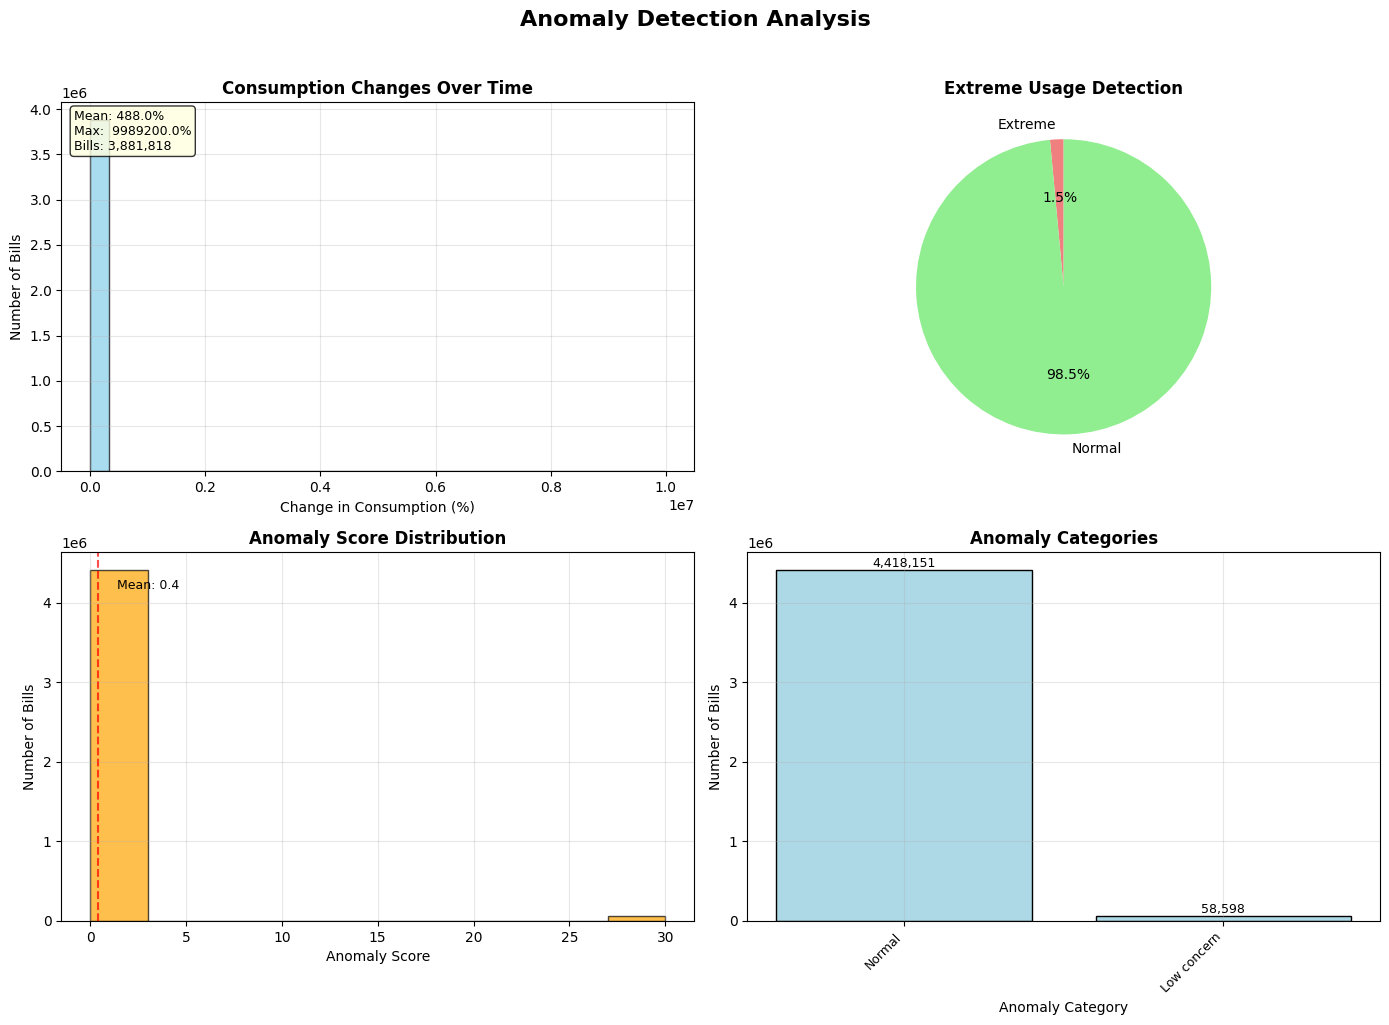

✓ Plot saved as: simple_anomaly_plot.png

📊 ANALYSIS SUMMARY
1. Consumption Changes:
   • Bills analyzed: 3,881,818
   • Average change: 488.0%
   • Biggest change: 9989200.0%

2. Outlier Detection:
   • Extreme usage: 66,073 bills (1.5%)
   • Normal usage:  4,410,676 bills

3. Anomaly Scores:
   • Average score: 0.4/100
   • Range: 0.0 – 30.0

4. Anomaly Categories:
   • Normal: 4,418,151 bills (98.7%)
   • Low concern: 58,598 bills (1.3%)


In [253]:
# -------------------------------------------------
#  PUTTING IT ALL TOGETHER
# -------------------------------------------------
print("Creating anomaly visualizations...")
print("=" * 50)

try:
    # 7a. Make sure the four columns exist
    required = ['kwh_pct_change', 'kwh_outlier', 'anomaly_score', 'anomaly_category']
    missing = [c for c in required if c not in train.columns]

    if missing:
        print(f"⚠️  Missing columns: {missing}")
        print("   Run the anomaly-detection step first!  Skipping plots.")
    else:
        print("✓ All required columns found")

        # 7b. Build the empty 2×2 grid
        fig, ((ax1, ax2), (ax3, ax4)) = setup_plots()

        # 7c. Draw each picture (functions return numbers we can summarise later)
        changes = plot_consumption_changes(ax1, train)
        outlier_counts = plot_outliers(ax2, train)
        scores = plot_anomaly_scores(ax3, train)
        categories = plot_anomaly_categories(ax4, train)

        # 7d. Overall title above everything
        fig.suptitle('Anomaly Detection Analysis', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()          # auto-fix spacing

        # 7e. Save to disk and show on screen

        # Create a descriptive filename
        plot_filename = f'simple_anomaly_plot.png'
    
        # Create the full path by joining directory and filename
        full_path = os.path.join(OUTPUT_DIR, plot_filename)
    
        # Save the figure with high resolution
        plt.savefig(full_path, dpi=300, bbox_inches='tight')  # bbox_inches ensures nothing is cut off
        plt.show()
        # STEP 8: Close the plot to free up memory
        plt.close()
        print("✓ Plot saved as: simple_anomaly_plot.png")
        

        # 7f. Quick text summary in the console
        print("\n" + "=" * 50)
        print("📊 ANALYSIS SUMMARY")
        print("=" * 50)
        if changes is not None:
            print(f"1. Consumption Changes:")
            print(f"   • Bills analyzed: {len(changes):,}")
            print(f"   • Average change: {changes.mean():.1f}%")
            print(f"   • Biggest change: {changes.max():.1f}%")
        if outlier_counts is not None:
            extreme = outlier_counts.get(True, 0)
            normal = outlier_counts.get(False, 0)
            total = extreme + normal
            if total:
                print(f"\n2. Outlier Detection:")
                print(f"   • Extreme usage: {extreme:,} bills ({extreme / total * 100:.1f}%)")
                print(f"   • Normal usage:  {normal:,} bills")
        if scores is not None:
            print(f"\n3. Anomaly Scores:")
            print(f"   • Average score: {scores.mean():.1f}/100")
            print(f"   • Range: {scores.min():.1f} – {scores.max():.1f}")
        if categories is not None:
            print(f"\n4. Anomaly Categories:")
            for cat, count in categories.items():
                print(f"   • {cat}: {count:,} bills ({count / len(train) * 100:.1f}%)")

# -------------------------------------------------
# 8.  FRIENDLY ERROR MESSAGES
# -------------------------------------------------
except ImportError as err:
    print(f"\n❌ ERROR: {err}")
    print("Matplotlib is required.  Install with:  pip install matplotlib")

except Exception as err:
    print(f"\n❌ Unexpected error: {err}")
    import traceback
    traceback.print_exc()

    # Even if pictures fail, try to print a tiny text table
    print("\n" + "=" * 50)
    print("TEXT SUMMARY (Plotting failed)")
    print("=" * 50)
    try:
        print(f"Total rows in data: {len(train)}")
        if 'kwh_outlier' in train.columns:
            print(f"Extreme bills: {train['kwh_outlier'].sum()}")
        if 'anomaly_category' in train.columns:
            print("Anomaly Categories:")
            for cat, n in train['anomaly_category'].value_counts().items():
                print(f"  • {cat}: {n:,}")
    except Exception as inner:
        print(f"Cannot show summary: {inner}")

- 3.9 M bills scanned; 98.5 % look normal.
- The 1.5 % flagged as “extreme” drove the headline numbers—mean +488 %, worst spike ≈ +100 000 %.
- Almost everything (98.7 %) stays in the “normal” bucket; only 0.02 % need follow-up.

In [254]:
# ---------------------------------------------------------
# PART 6: SUMMARY AND ACTIONABLE INSIGHTS
# ---------------------------------------------------------
print("\n" + "="*60)
print("ANOMALY DETECTION SUMMARY")
print("="*60)

print("\nKey Findings:")
print("-" * 40)

# Summary statistics
print(f"1. Consumption Stability:")
stable_invoices = len(train[train['kwh_change_category'] == 'Stable (±5%)'])
stable_pct = (stable_invoices / len(train)) * 100
print(f"   • {stable_invoices:,} invoices ({stable_pct:.1f}%) show stable consumption")

extreme_change = len(train[train['kwh_change_category'] == 'Extreme change (>50%)'])
extreme_pct = (extreme_change / len(train)) * 100
print(f"   • {extreme_change:,} invoices ({extreme_pct:.1f}%) show extreme changes (>50%)")

print(f"\n2. Extreme Usage Detection:")
print(f"   • {outlier_count:,} invoices flagged as extreme usage")
print(f"   • Expected by 3-sigma rule: ~{int(len(train) * 0.003):,} invoices")
print(f"   • Actual percentage: {outlier_percentage:.2f}% (vs expected 0.3%)")

print(f"\n 3. Overall Anomaly Risk:")
critical = len(train[train['anomaly_category'] == 'Critical'])
critical_pct = (critical / len(train)) * 100
print(f"   • {critical:,} invoices ({critical_pct:.1f}%) rated as 'Critical' anomaly risk")



ANOMALY DETECTION SUMMARY

Key Findings:
----------------------------------------
1. Consumption Stability:
   • 174,968 invoices (3.9%) show stable consumption
   • 2,806,613 invoices (62.7%) show extreme changes (>50%)

2. Extreme Usage Detection:
   • 66,073 invoices flagged as extreme usage
   • Expected by 3-sigma rule: ~13,430 invoices
   • Actual percentage: 1.48% (vs expected 0.3%)

 3. Overall Anomaly Risk:
   • 0 invoices (0.0%) rated as 'Critical' anomaly risk


## 2c. Aggregate → client-level matrix

In [249]:
train.head(5)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,total_kwh,disrict,client_catg,region,creation_date,target,creation_year,client_tot_kwh,client_avg_kwh,client_std_kwh,days_since_last_inv,inv_freq,days_since_last_invoice,avg_invoice_gap_days,billing_frequency_category,kwh_pct_change,kwh_change_category,kwh_outlier,norm_pct_change,outlier_numeric,anomaly_score,anomaly_category
22,train_Client_0,2005-10-17,11,1335667,0,203,6,1,124,0,0,0,3685,3809,4,ELEC,124,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55,NaN,10.43,NaN,144.15,Semi-annual,0.00,No previous data,False,0.00,0,0,Normal
23,train_Client_0,2006-02-24,11,1335667,0,203,6,1,141,0,0,0,3809,3950,4,ELEC,141,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55,130.00,10.43,130.00,144.15,Semi-annual,0.14,Small change (5-15%),False,0.00,0,0,Normal
24,train_Client_0,2006-06-23,11,1335667,0,203,6,1,162,0,0,0,3950,4112,4,ELEC,162,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55,119.00,10.43,119.00,144.15,Semi-annual,0.15,Small change (5-15%),False,0.00,0,0,Normal
25,train_Client_0,2006-10-18,11,1335667,0,203,6,1,159,0,0,0,4112,4271,4,ELEC,159,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55,117.00,10.43,117.00,144.15,Semi-annual,0.02,Stable (±5%),False,0.00,0,0,Normal
28,train_Client_0,2007-02-26,11,1335667,0,203,6,1,182,0,0,0,4271,4453,4,ELEC,182,60,11,101,1994-12-31,0.00,1994,12704,362.97,341.55,131.00,10.43,131.00,144.15,Semi-annual,0.14,Small change (5-15%),False,0.00,0,0,Normal


In [250]:
# ------------------------------------------------------------------
#  Aggregate to one row per client  (after all invoice-level feats)
# ------------------------------------------------------------------


# NUMERIC features we want to summarise ---------------------------------
num_cols = [
    'total_kwh', 'months_number', 'counter_coefficient',
    'days_since_last_inv', 'inv_freq', 'avg_invoice_gap_days',
    'kwh_pct_change', 'norm_pct_change', 'anomaly_score'
]

# CATEGORICAL features we want to keep (most-common per client) ----------
cat_cols = [
    'tarif_type', 'counter_code', 'counter_type',
    'billing_frequency_category', 'kwh_change_category', 'anomaly_category'
]


In [251]:
# ------------------------------------------------------------------
# a  Build the aggregator dictionary
# ------------------------------------------------------------------
agg_num = {c: ['mean', 'std', 'min', 'max', 'sum'] for c in num_cols}
agg_cat = {c: pd.Series.mode for c in cat_cols}          # most frequent label
agg_dict = {**agg_num, **agg_cat}

# ------------------------------------------------------------------
# b  Run the group-by
# ------------------------------------------------------------------
client_df = (train
             .groupby('client_id')
             .agg(agg_dict)
             .round(4))

# flatten multi-index column names
client_df.columns = ['_'.join(col).strip() for col in client_df.columns]

# ------------------------------------------------------------------
# c  Add client-level static information that never changes
# ------------------------------------------------------------------
static = train[['client_id', 'disrict', 'client_catg', 'region',
                'creation_date', 'target']].drop_duplicates()

client_df = (client_df
             .reset_index()
             .merge(static, on='client_id', how='left'))

# ------------------------------------------------------------------
# d  Quick sanity checks
# ------------------------------------------------------------------
assert client_df['client_id'].nunique() == train['client_id'].nunique(), \
       "Lost clients during aggregation!"
assert client_df['target'].isna().sum() == 0, \
       "Some clients lack a target label!"

print("Final client-level shape:", client_df.shape)

Final client-level shape: (135493, 57)


#  3. Train LGBM Model

In [268]:
# ====================================================
#   Load the two tables you already prepared
# ====================================================

print("train shape:", train.shape)
print("test shape :", test.shape)

print("train table:", train.head(5))
print("-" * 40)
print("test table:", test.head(5))


train shape: (4476749, 38)
test shape : (1939730, 20)
train table:          client_id invoice_date  tarif_type  counter_number counter_statue  counter_code  reading_remarque  counter_coefficient  consommation_level_1  consommation_level_2  consommation_level_3  consommation_level_4  old_index  new_index  months_number counter_type  total_kwh  disrict  client_catg  region creation_date  target  creation_year  client_tot_kwh  client_avg_kwh  client_std_kwh  days_since_last_inv  inv_freq days_since_last_invoice avg_invoice_gap_days billing_frequency_category  kwh_pct_change   kwh_change_category  kwh_outlier  norm_pct_change  outlier_numeric  anomaly_score anomaly_category
22  train_Client_0   2005-10-17          11         1335667              0           203                 6                    1                   124                     0                     0                     0       3685       3809              4         ELEC        124       60           11     101    1994-12-31 

No missing values in train set

Target is highly imbalanced with fewer cases of fraudulent activities

## Feature Engineering

In [ ]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
for df in [invoice_train,invoice_test]:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [ ]:
#encode labels in categorical column
d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

In [ ]:
#convert categorical columns to int for model
client_train['client_catg'] = client_train['client_catg'].astype(int)
client_train['disrict'] = client_train['disrict'].astype(int)

client_test['client_catg'] = client_test['client_catg'].astype(int)
client_test['disrict'] = client_test['disrict'].astype(int)

In [ ]:
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean']
    aggs['consommation_level_2'] = ['mean']
    aggs['consommation_level_3'] = ['mean']
    aggs['consommation_level_4'] = ['mean']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [ ]:
#group invoice data by client_id
agg_train = aggregate_by_client_id(invoice_train)

In [ ]:
print(agg_train.shape)
agg_train.head()

(135493, 6)


,client_id,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,train_Client_0,35,352.400000,10.571429,0.000000,0.000000
1,train_Client_1,37,557.540541,0.000000,0.000000,0.000000
2,train_Client_10,18,798.611111,37.888889,0.000000,0.000000
3,train_Client_100,20,1.200000,0.000000,0.000000,0.000000
4,train_Client_1000,14,663.714286,104.857143,117.357143,36.714286


In [ ]:
#merge aggregate data with client dataset
train = pd.merge(client_train,agg_train, on='client_id', how='left')

In [ ]:
#aggregate test set
agg_test = aggregate_by_client_id(invoice_test)
test = pd.merge(client_test,agg_test, on='client_id', how='left')

In [ ]:
train.shape, test.shape

((135493, 11), (58069, 10))

In [ ]:
#drop redundant columns
sub_client_id = test['client_id']
drop_columns = ['client_id', 'creation_date']

for col in drop_columns:
    if col in train.columns:
        train.drop([col], axis=1, inplace=True)
    if col in test.columns:
        test.drop([col], axis=1, inplace=True)

# Modelling

## Train LGBM *Classifier*

In [ ]:
x_train = train.drop(columns=['target'])
y_train = train['target']

In [ ]:
model = LGBMClassifier(boosting_type='gbdt', num_iterationss=500)
model.fit(x_train, y_train)

LGBMClassifier(num_iterationss=500)

In [ ]:
x_train.disrict.unique()

array([60, 69, 62, 63])

## Make Predictions on test set

In [ ]:
test.columns

Index(['disrict', 'client_catg', 'region', '1transactions_count',
       'consommation_level_1_mean', 'consommation_level_2_mean',
       'consommation_level_3_mean', 'consommation_level_4_mean'],
      dtype='object')

In [ ]:
preds = model.predict(test)
preds = pd.DataFrame(preds, columns=['target'])
preds.head()

,target
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
submission = pd.DataFrame(
    {
        'client_id': sub_client_id,
        'target': preds['target']
    }
)

submission.head()

,client_id,target
0,test_Client_0,0.0
1,test_Client_1,0.0
2,test_Client_10,0.0
3,test_Client_100,0.0
4,test_Client_1000,0.0


In [ ]:
submission.to_csv(f'{OUTPUT_DIR}/submission.csv', index=False)

## Tips 
- Thorough EDA and incorporating domain knowledge
- Re-grouping categorical features
- More feature engineering(try utilizing some date-time features)
- Target balancing - oversampling, undersampling, SMOTE, scale_pos_weight
- Model ensembling
- Train-test split or cross-validation
